***problem statement is predicticing whether customer receive on <=50k and >50k***

In [2]:
#import libraries
import pandas as pd#data handling 
import numpy as np#numerical operations and data handling

In [3]:
#load dataset
data=pd.read_csv('salary.csv')
data

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K
...,...,...,...,...,...
32556,22,10,0,40,<=50K
32557,27,12,0,38,<=50K
32558,40,9,0,40,>50K
32559,58,9,0,40,<=50K


In [4]:
#summarize dataset
data.shape
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   education.num   32561 non-null  int64 
 2   capital.gain    32561 non-null  int64 
 3   hours.per.week  32561 non-null  int64 
 4   income          32561 non-null  object
dtypes: int64(4), object(1)
memory usage: 1.2+ MB


In [5]:
#using maping but some error issue facing ,so i have using label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['income']=le.fit_transform(data['income'])
print(data['income'].tail())

32556    0
32557    0
32558    1
32559    0
32560    0
Name: income, dtype: int64


In [6]:
#check null values
data.isnull().sum()
data.describe()#statistical summary

,age,education.num,capital.gain,hours.per.week,income
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,40.437456,0.240810
std,13.640433,2.572720,7385.292085,12.347429,0.427581
min,17.000000,1.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,40.000000,0.000000
75%,48.000000,12.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,99.000000,1.000000


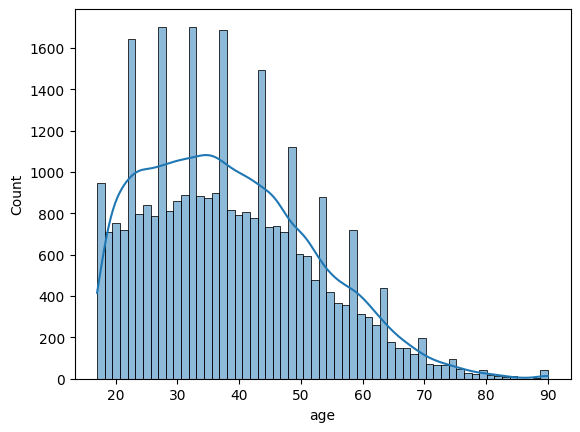

In [7]:
#exploratory data analysis
import matplotlib.pyplot as plt#visuvalization graph
import seaborn as sns#advanced visuvalization

sns.histplot(data['age'],kde=True) #slightly normal distribution
plt.show()

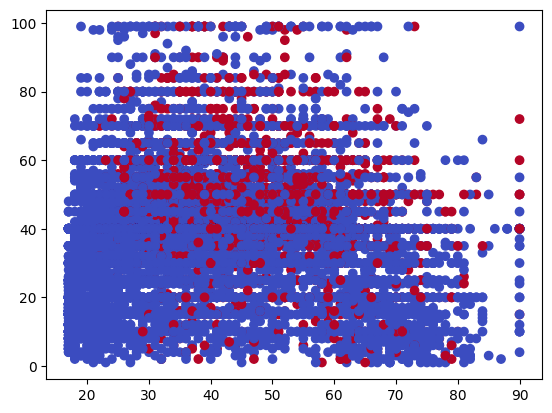

In [8]:
#scatterplot between two realtionship on datas
plt.scatter(data['age'],data['hours.per.week'],c=data['income'],cmap='coolwarm')
plt.show()
#majority people salary receive <=50k blue color,red color >50k
#this dataset is imbalanced 75% and 25 % the model is biased

<Axes: >

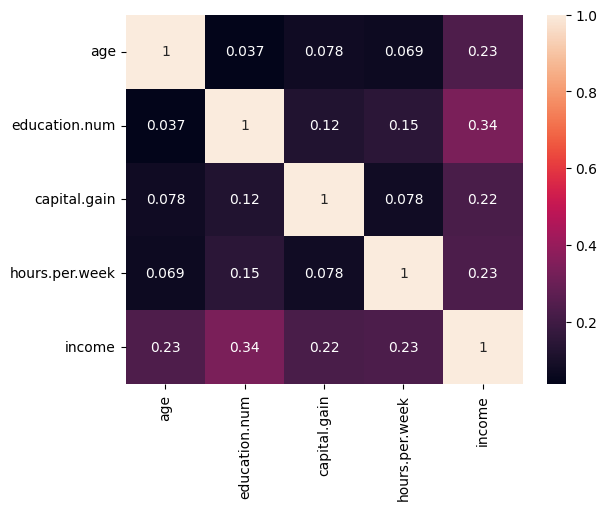

In [9]:
#correlation
sns.heatmap(data.corr(),annot=True)

In [10]:
#segregate features 
x=data.iloc[:,:-1].values
x

array([[90,  9,  0, 40],
       [82,  9,  0, 18],
       [66, 10,  0, 40],
       ...,
       [40,  9,  0, 40],
       [58,  9,  0, 40],
       [22,  9,  0, 20]], shape=(32561, 4))

In [11]:
#segreagte labels
y=data.iloc[:,-1].values
y

array([0, 0, 0, ..., 1, 0, 0], shape=(32561,))

In [12]:
#splitting dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train,x_test)

[[  55    3    0   40]
 [  42    9    0   40]
 [  42    9    0   40]
 ...
 [  26    8    0   51]
 [  44   14    0   40]
 [  39    9 7298   40]] [[56  5  0 40]
 [19  9  0 25]
 [23 10  0 35]
 ...
 [44 10  0 55]
 [58  9  0 50]
 [55 10  0 45]]


In [13]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
print(x_train,x_test)

[[ 1.20264866 -2.76154633 -0.14509813 -0.03923011]
 [ 0.25021666 -0.42608063 -0.14509813 -0.03923011]
 [ 0.25021666 -0.42608063 -0.14509813 -0.03923011]
 ...
 [-0.92200734 -0.81532491 -0.14509813  0.85306386]
 [ 0.39674466  1.52014079 -0.14509813 -0.03923011]
 [ 0.03042466 -0.42608063  0.83219401 -0.03923011]] [[ 1.27591266 -1.98305776 -0.14509813 -0.03923011]
 [-1.43485534 -0.42608063 -0.14509813 -1.25599461]
 [-1.14179934 -0.03683634 -0.14509813 -0.44481828]
 ...
 [ 0.39674466 -0.03683634 -0.14509813  1.1775344 ]
 [ 1.42244067 -0.42608063 -0.14509813  0.77194623]
 [ 1.20264866 -0.03683634 -0.14509813  0.36635806]]


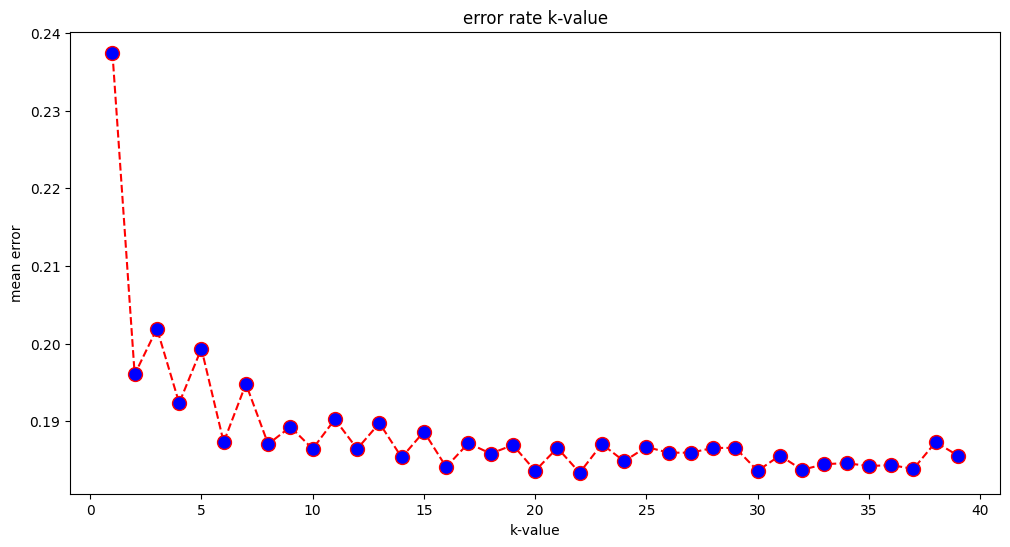

In [14]:
#finding the k value
error=[]
from sklearn.neighbors import KNeighborsClassifier
#calculating error for k value between 1 and 40
for i in range(1,40):
    model= KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    pred_i=model.predict(x_test)
    error.append(np.mean(pred_i!=y_test))
plt.figure(figsize=(12,6))
plt.plot(range(1,40),error,color='red',linestyle='dashed',marker='o',markerfacecolor='blue',markersize=10)
plt.title('error rate k-value')
plt.xlabel('k-value')
plt.ylabel('mean error')
plt.show()

In [15]:
#training
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=2,metric='minkowski',p=2)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=2)

In [16]:
#predicting all test data
y_pred=model.predict(x_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [17]:
#accuracy score and confusion matrix using metrics 
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,y_pred)*100)
print(confusion_matrix(y_pred,y_test))

80.39552880481513
[[5916 1319]
 [ 277  629]]


In [18]:
#predicting whether salary how many peoples <=50k and >50k
age=int(input("enter the customer age:"))
hours=int(input("enter the customer hours:"))
edu=int(input("enter the edu:"))
cg=int(input("enter the cg:"))
newcust=[[age,hours,edu,cg]]
result=model.predict(sc.transform(newcust))
print(result)
if result==1:
    print("customer receive on >50k")
else:
    print("customer receive on <=50k")

[0]
customer receive on <=50k


In [19]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
print("Model saved!")

Model saved!


In [20]:
model=pickle.load(open('model.pkl','rb'))
print(model)

KNeighborsClassifier(n_neighbors=2)
